# Лабораторная 6

### 1.1 Импорт библиотек и базовая конфигурация


In [1]:
from pathlib import Path

import contextlib
import io
import json
import math
import os
import random
import shutil
from collections import defaultdict

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
import yaml

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = 0
else:
    DEVICE = "cpu"

ROOT_DIR = Path("lab6_data")
TRAIN_RAW_DIR = ROOT_DIR / "sign_dataset" / "train"
VAL_RAW_DIR = ROOT_DIR / "sign_dataset" / "val"
TRAIN_VIA_PATH = TRAIN_RAW_DIR / "via_region_data.json"
VAL_VIA_PATH = VAL_RAW_DIR / "via_region_data.json"

YOLO_DATASET_DIR = ROOT_DIR / "yolo_sign_dataset"
DATA_YAML = YOLO_DATASET_DIR / "data.yaml"
RUNS_DIR = ROOT_DIR / "runs_seg"

CUSTOM_RAW_DIR = Path("images")
CUSTOM_ANN_PATH = CUSTOM_RAW_DIR / "instances_default.json"
OUTPUT_DIR = Path("output")
CUSTOM_GT_MASKS_DIR = OUTPUT_DIR / "gt_masks"
CUSTOM_PRED_MASKS_DIR = OUTPUT_DIR / "pred_masks"
CUSTOM_OVERLAY_DIR = OUTPUT_DIR / "overlay"

for folder in [ROOT_DIR, YOLO_DATASET_DIR, RUNS_DIR, OUTPUT_DIR, CUSTOM_GT_MASKS_DIR, CUSTOM_PRED_MASKS_DIR, CUSTOM_OVERLAY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "yolo11s-seg.pt"
IMG_SIZE = 512
EPOCHS = 5
BATCH = 8
WORKERS = 2
TRAIN_FRACTION = 1.0
MAX_TRAIN_IMAGES = None
CONF_THRES = 0.25
MAX_SIGN_AREA_RATIO = 0.08
MAX_SIGN_BOX_AREA_RATIO = 0.12
TRAIN_MODEL = True
RUN_NAME = "yolo_signs_seg_via_local"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


## 2. Подготовка датасета


### 2.1 Функции для чтения изображений и VIA-разметки


In [2]:
def list_images(folder: Path):
    image_paths = []
    for ext in IMG_EXTS:
        image_paths.extend(sorted(folder.glob(f"*{ext}")))
    return sorted(image_paths)


def load_split_items(via_path: Path):
    with open(via_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return list(data.values())


def extract_regions(item):
    regions = item.get("regions", {})
    if isinstance(regions, list):
        return regions
    return list(regions.values())


def is_sign_region(region):
    region_attrs = region.get("region_attributes", {})
    name = region_attrs.get("name")
    return name in (None, "", "road sign")


def shape_to_points(region, width, height, circle_steps=24):
    shape = region.get("shape_attributes", {})
    shape_name = shape.get("name")
    points = []

    if shape_name == "polygon":
        xs = shape.get("all_points_x", [])
        ys = shape.get("all_points_y", [])
        if len(xs) >= 3 and len(xs) == len(ys):
            points = [[float(x), float(y)] for x, y in zip(xs, ys)]

    elif shape_name == "ellipse":
        cx = float(shape.get("cx", 0))
        cy = float(shape.get("cy", 0))
        rx = float(shape.get("rx", 0))
        ry = float(shape.get("ry", 0))
        if rx > 0 and ry > 0:
            for t in np.linspace(0, 2 * math.pi, circle_steps, endpoint=False):
                x = cx + rx * math.cos(t)
                y = cy + ry * math.sin(t)
                points.append([x, y])

    elif shape_name == "circle":
        cx = float(shape.get("cx", 0))
        cy = float(shape.get("cy", 0))
        r = float(shape.get("r", 0))
        if r > 0:
            for t in np.linspace(0, 2 * math.pi, circle_steps, endpoint=False):
                x = cx + r * math.cos(t)
                y = cy + r * math.sin(t)
                points.append([x, y])

    clipped = []
    for x, y in points:
        x = min(max(float(x), 0.0), max(width - 1, 0))
        y = min(max(float(y), 0.0), max(height - 1, 0))
        clipped.append([x, y])

    if len(clipped) < 3:
        return []

    return clipped


### 2.2 Функции для чтения YOLO-сегментации и имён классов


In [3]:
def ensure_link(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    try:
        os.symlink(src.resolve(), dst)
    except Exception:
        shutil.copy2(src, dst)


def convert_split_to_yolo(via_path: Path, split_name: str, out_root: Path, fraction=1.0, max_images=None):
    items = load_split_items(via_path)

    if split_name == "train":
        random.shuffle(items)
        if 0 < fraction < 1:
            items = items[: max(1, int(len(items) * fraction))]
        if max_images is not None:
            items = items[:max_images]

    images_dir = out_root / "images" / split_name
    labels_dir = out_root / "labels" / split_name
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

    images_count = 0
    empty_labels = 0
    non_empty_labels = 0

    for item in items:
        filename = item.get("filename")
        if not filename:
            continue

        image_path = via_path.parent / filename
        if not image_path.exists():
            continue

        image = cv2.imread(str(image_path))
        if image is None:
            continue

        h, w = image.shape[:2]
        lines = []

        for region in extract_regions(item):
            if not is_sign_region(region):
                continue

            points = shape_to_points(region, w, h)
            if len(points) < 3:
                continue

            coords = []
            for x, y in points:
                coords.append(f"{x / w:.6f}")
                coords.append(f"{y / h:.6f}")

            if len(coords) >= 6:
                lines.append("0 " + " ".join(coords))

        dst_image = images_dir / filename
        dst_label = labels_dir / f"{Path(filename).stem}.txt"

        ensure_link(image_path, dst_image)
        with open(dst_label, "w", encoding="utf-8") as f:
            f.write("\n".join(lines))

        images_count += 1
        if lines:
            non_empty_labels += 1
        else:
            empty_labels += 1

    return {
        "split": split_name,
        "images": images_count,
        "empty_labels": empty_labels,
        "non_empty_labels": non_empty_labels,
    }


def build_data_yaml(out_root: Path):
    data = {
        "path": str(out_root.resolve()),
        "train": "images/train",
        "val": "images/val",
        "names": {0: "road_sign"},
    }
    yaml_path = out_root / "data.yaml"
    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, allow_unicode=True, sort_keys=False)
    return yaml_path


### 2.3 Визуализация примеров и сбор статистики по датасету


In [4]:
def show_random_samples(images_dir: Path, labels_dir: Path, n=6):
    image_paths = list_images(images_dir)
    if not image_paths:
        return

    sample_paths = random.sample(image_paths, k=min(n, len(image_paths)))
    plt.figure(figsize=(15, 10))

    for idx, image_path in enumerate(sample_paths, start=1):
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        label_path = labels_dir / f"{image_path.stem}.txt"

        if label_path.exists():
            with open(label_path, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 7:
                        continue
                    coords = np.array(list(map(float, parts[1:])), dtype=np.float32).reshape(-1, 2)
                    coords[:, 0] *= w
                    coords[:, 1] *= h
                    coords = np.round(coords).astype(np.int32)
                    cv2.polylines(image, [coords], True, (255, 0, 0), 2)

        plt.subplot((len(sample_paths) + 2) // 3, 3, idx)
        plt.imshow(image)
        plt.title(image_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


### 2.4 Сводная статистика по обучающей и валидационной выборкам


,split,images,empty_labels,non_empty_labels
0,train,2054,1,2053
1,val,127,0,127


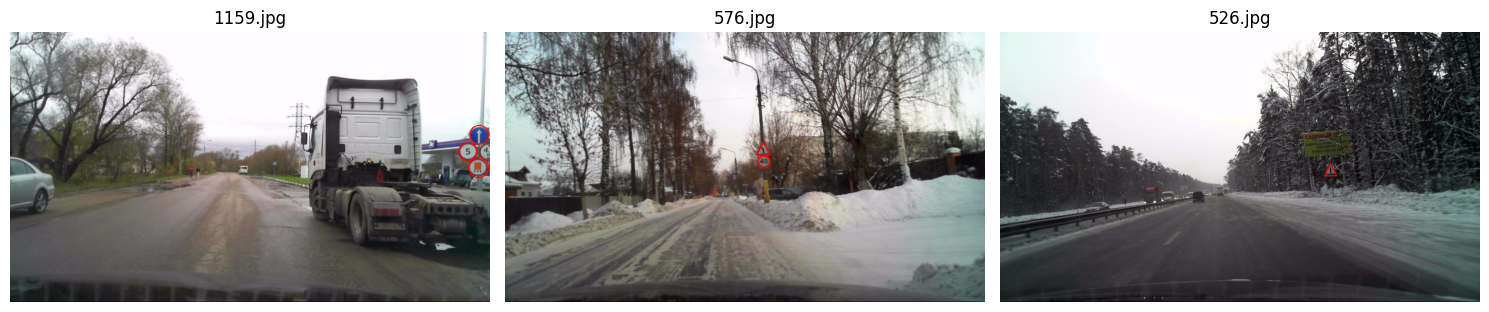

In [5]:
if YOLO_DATASET_DIR.exists():
    shutil.rmtree(YOLO_DATASET_DIR)

train_info = convert_split_to_yolo(
    TRAIN_VIA_PATH,
    "train",
    YOLO_DATASET_DIR,
    fraction=TRAIN_FRACTION,
    max_images=MAX_TRAIN_IMAGES,
)

val_info = convert_split_to_yolo(
    VAL_VIA_PATH,
    "val",
    YOLO_DATASET_DIR,
)

DATA_YAML = build_data_yaml(YOLO_DATASET_DIR)
CLASS_NAMES = {0: "road_sign"}

display(pd.DataFrame([train_info, val_info]))
show_random_samples(
    YOLO_DATASET_DIR / "images" / "train",
    YOLO_DATASET_DIR / "labels" / "train",
    n=3,
)


## 3. Обучение модели


### 3.1 Выбор готовых весов или запуск обучения


In [6]:
def find_latest_best_weights(runs_dir: Path):
    candidates = sorted(runs_dir.glob("*/weights/best.pt"), key=lambda path: path.stat().st_mtime)
    return candidates[-1] if candidates else None


existing_weights = find_latest_best_weights(RUNS_DIR)

if TRAIN_MODEL:
    model = YOLO(MODEL_NAME)
    train_results = model.train(
        data=str(DATA_YAML),
        imgsz=IMG_SIZE,
        epochs=EPOCHS,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        optimizer="AdamW",
        lr0=0.002,
        weight_decay=0.0005,
        patience=6,
        save=True,
        project=str(RUNS_DIR),
        name=RUN_NAME,
        pretrained=True,
        val=True,
        plots=False,
        verbose=True,
    )
    model_path = Path(train_results.save_dir) / "weights" / "best.pt"
    results_csv = Path(train_results.save_dir) / "results.csv"
elif existing_weights is not None:
    model_path = existing_weights
    results_csv = model_path.parents[1] / "results.csv"
else:
    raise FileNotFoundError("Не найдено обученных весов в runs_seg. Запустите обучение с TRAIN_MODEL=True")

best_model = YOLO(str(model_path))
print(model_path)


New https://pypi.org/project/ultralytics/8.4.43 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.37 🚀 Python-3.12.2 torch-2.10.0 MPS (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=lab6_data/yolo_sign_dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_signs_

### 3.2 История обучения по mAP-метрикам


In [7]:
history_df = pd.read_csv(results_csv)

display(
    history_df[
        [
            "epoch",
            "metrics/mAP50(B)",
            "metrics/mAP50-95(B)",
            "metrics/mAP50(M)",
            "metrics/mAP50-95(M)",
        ]
    ]
)


,epoch,metrics/mAP50(B),metrics/mAP50-95(B),metrics/mAP50(M),metrics/mAP50-95(M)
0,1,0.39960,0.20717,0.27582,0.08708
1,2,0.32203,0.18553,0.27340,0.07851
2,3,0.32553,0.18648,0.29526,0.13283
3,4,0.50947,0.29503,0.41453,0.16862
4,5,0.64748,0.39587,0.53812,0.25003


### 3.3 Встроенная валидация Ultralytics на split `val`


In [8]:
with contextlib.redirect_stdout(io.StringIO()):
    val_builtin = best_model.val(
        data=str(DATA_YAML),
        imgsz=IMG_SIZE,
        batch=BATCH,
        device=DEVICE,
        split="val",
        verbose=False,
        plots=False,
    )

print(model_path)
print(val_builtin.results_dict)


Ultralytics 8.4.37 🚀 Python-3.12.2 torch-2.10.0 MPS (Apple M1)
YOLO11s-seg summary (fused): 114 layers, 10,067,203 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 445.9±409.4 MB/s, size: 1344.5 KB)
WARNING ⚠️ NMS time limit 2.350s exceeded
                   all        127        400      0.811       0.71      0.777      0.482      0.743      0.652      0.667      0.319
Speed: 1.6ms preprocess, 186.0ms inference, 0.0ms loss, 98.3ms postprocess per image
/Users/nikitagerasimov/Desktop/Study/6 semestr/CV/CV-GerasimovNS-M3303/runs/segment/lab6_data/runs_seg/yolo_signs_seg_via_local7/weights/best.pt
{'metrics/precision(B)': 0.8106695269083634, 'metrics/recall(B)': 0.71, 'metrics/mAP50(B)': 0.7774676976401802, 'metrics/mAP50-95(B)': 0.4818334226568923, 'metrics/precision(M)': 0.7434135576820242, 'metrics/recall(M)': 0.6525, 'metrics/mAP50(M)': 0.666874199084748, 'metrics/mAP50-95(M)': 0.3191315355710216, 'fitness': 0.8009649582279139}


## 4. Метрики на валидации


### 4.1 Построение бинарной маски из эталонной разметки


In [9]:
def annotation_to_mask(item, image_shape):
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    for region in extract_regions(item):
        if not is_sign_region(region):
            continue

        shape = region.get("shape_attributes", {})
        shape_name = shape.get("name")

        if shape_name == "polygon":
            xs = shape.get("all_points_x", [])
            ys = shape.get("all_points_y", [])
            if len(xs) >= 3 and len(xs) == len(ys):
                pts = np.array(list(zip(xs, ys)), dtype=np.int32)
                cv2.fillPoly(mask, [pts], 1)

        elif shape_name == "ellipse":
            cx = int(round(shape.get("cx", 0)))
            cy = int(round(shape.get("cy", 0)))
            rx = int(round(shape.get("rx", 0)))
            ry = int(round(shape.get("ry", 0)))
            if rx > 0 and ry > 0:
                cv2.ellipse(mask, (cx, cy), (rx, ry), 0, 0, 360, 1, -1)

        elif shape_name == "circle":
            cx = int(round(shape.get("cx", 0)))
            cy = int(round(shape.get("cy", 0)))
            r = int(round(shape.get("r", 0)))
            if r > 0:
                cv2.circle(mask, (cx, cy), r, 1, -1)

    return mask


### 4.2 Предсказание маски и расчёт метрик качества


In [10]:
def extract_sign_detections(result, image_shape, conf=0.25, max_mask_area_ratio=MAX_SIGN_AREA_RATIO, max_box_area_ratio=MAX_SIGN_BOX_AREA_RATIO):
    h, w = image_shape[:2]
    detections = []

    if result.boxes is None or len(result.boxes) == 0:
        return detections

    boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
    scores = result.boxes.conf.detach().cpu().numpy()
    classes = result.boxes.cls.detach().cpu().numpy().astype(int)
    mask_polys = result.masks.xy if result.masks is not None else [None] * len(boxes_xyxy)

    for box, score, cls_id, poly in zip(boxes_xyxy, scores, classes, mask_polys):
        if score < conf:
            continue

        x1, y1, x2, y2 = box.astype(int)
        box_area_ratio = max(x2 - x1, 0) * max(y2 - y1, 0) / (h * w)
        if box_area_ratio > max_box_area_ratio:
            continue

        polygon = None
        mask_area_ratio = 0.0
        if poly is not None and len(poly) >= 3:
            polygon = np.round(np.array(poly)).astype(np.int32)
            mask_area_ratio = abs(cv2.contourArea(polygon)) / (h * w)
            if mask_area_ratio > max_mask_area_ratio:
                continue

        detections.append(
            {
                "cls_id": cls_id,
                "score": float(score),
                "box": (x1, y1, x2, y2),
                "polygon": polygon,
            }
        )

    return detections


def predict_union_mask(model, image_path: Path, conf=0.25):
    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]
    pred_mask = np.zeros((h, w), dtype=np.uint8)

    result = model.predict(
        source=str(image_path),
        imgsz=IMG_SIZE,
        conf=conf,
        device=DEVICE,
        verbose=False,
    )[0]

    for det in extract_sign_detections(result, image.shape, conf=conf):
        if det["polygon"] is not None and len(det["polygon"]) >= 3:
            cv2.fillPoly(pred_mask, [det["polygon"]], 1)
        else:
            x1, y1, x2, y2 = det["box"]
            cv2.rectangle(pred_mask, (x1, y1), (x2, y2), 1, -1)

    return pred_mask


def calc_metrics(gt_mask, pred_mask):
    gt = (gt_mask > 0).astype(np.uint8)
    pred = (pred_mask > 0).astype(np.uint8)

    tp = int(((gt == 1) & (pred == 1)).sum())
    fp = int(((gt == 0) & (pred == 1)).sum())
    fn = int(((gt == 1) & (pred == 0)).sum())

    iou = tp / (tp + fp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    l2 = float(np.sqrt(np.mean((gt.astype(np.float32) - pred.astype(np.float32)) ** 2)))

    return {
        "IoU": iou,
        "Precision": precision,
        "Recall": recall,
        "L2": l2,
    }


### 4.3 Оценка всей валидационной выборки


In [11]:
def evaluate_split(model, via_path: Path, images_dir: Path, conf=0.25):
    rows = []
    items = load_split_items(via_path)

    for item in items:
        filename = item.get("filename")
        if not filename:
            continue

        image_path = images_dir / filename
        if not image_path.exists():
            continue

        image = cv2.imread(str(image_path))
        if image is None:
            continue

        gt_mask = annotation_to_mask(item, image.shape)
        pred_mask = predict_union_mask(model, image_path, conf=conf)
        metrics = calc_metrics(gt_mask, pred_mask)
        rows.append({"image": filename, **metrics})

    df = pd.DataFrame(rows)
    summary = pd.DataFrame(
        [
            {
                "images": len(df),
                "IoU_mean": df["IoU"].mean(),
                "Precision_mean": df["Precision"].mean(),
                "Recall_mean": df["Recall"].mean(),
                "L2_mean": df["L2"].mean(),
                "IoU>=0.5_%": (df["IoU"] >= 0.5).mean() * 100,
                "IoU>=0.75_%": (df["IoU"] >= 0.75).mean() * 100,
                "IoU>=0.9_%": (df["IoU"] >= 0.9).mean() * 100,
            }
        ]
    )
    return df, summary


### 4.4 Итоговая таблица по валидации


In [12]:
val_df, val_summary = evaluate_split(
    best_model,
    VAL_VIA_PATH,
    VAL_RAW_DIR,
    conf=CONF_THRES,
)

display(val_summary)


,images,IoU_mean,Precision_mean,Recall_mean,L2_mean,IoU>=0.5_%,IoU>=0.75_%,IoU>=0.9_%
0,127,0.515704,0.595035,0.807249,0.065999,56.692913,8.661417,0.0


## 5. Собственные фотографии


### 5.1 Загрузка COCO-разметки и построение эталонных масок


In [13]:
def load_coco_annotations(coco_path: Path):
    with open(coco_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    image_by_id = {image["id"]: image for image in coco.get("images", [])}
    anns_by_image = defaultdict(list)
    for ann in coco.get("annotations", []):
        anns_by_image[ann["image_id"]].append(ann)

    categories = {category["id"]: category["name"] for category in coco.get("categories", [])}
    return image_by_id, anns_by_image, categories


def coco_annotation_to_mask(image_info, annotations):
    h = image_info["height"]
    w = image_info["width"]
    mask = np.zeros((h, w), dtype=np.uint8)

    for ann in annotations:
        for polygon in ann.get("segmentation", []):
            if len(polygon) < 6:
                continue
            pts = np.array(polygon, dtype=np.float32).reshape(-1, 2)
            pts = np.round(pts).astype(np.int32)
            cv2.fillPoly(mask, [pts], 255)

    return mask


### 5.2 Инференс на пользовательских изображениях и сохранение результатов


In [14]:
def draw_sign_detections(image, detections, class_names):
    overlay = image.copy()
    palette = plt.cm.get_cmap("tab10", max(len(class_names), 1))

    for det in detections:
        cls_id = det["cls_id"]
        x1, y1, x2, y2 = det["box"]
        color = tuple(int(channel * 255) for channel in palette(cls_id % palette.N)[:3])
        color_bgr = (color[2], color[1], color[0])

        if det["polygon"] is not None and len(det["polygon"]) >= 3:
            cv2.fillPoly(overlay, [det["polygon"]], color_bgr)
            cv2.polylines(overlay, [det["polygon"]], True, color_bgr, 2)

        cv2.rectangle(overlay, (x1, y1), (x2, y2), color_bgr, 2)
        cv2.putText(
            overlay,
            f"road_sign: {det['score']:.2f}",
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color_bgr,
            2,
            cv2.LINE_AA,
        )

    return cv2.addWeighted(overlay, 0.35, image, 0.65, 0)


def save_custom_predictions(model, image_dir: Path, pred_masks_dir: Path, overlay_dir: Path, conf=0.25):
    if pred_masks_dir.exists():
        shutil.rmtree(pred_masks_dir)
    if overlay_dir.exists():
        shutil.rmtree(overlay_dir)

    pred_masks_dir.mkdir(parents=True, exist_ok=True)
    overlay_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    image_paths = list_images(image_dir)

    for image_path in image_paths:
        image = cv2.imread(str(image_path))
        if image is None:
            continue

        result = model.predict(
            source=str(image_path),
            imgsz=IMG_SIZE,
            conf=conf,
            device=DEVICE,
            verbose=False,
        )[0]

        detections = extract_sign_detections(result, image.shape, conf=conf)
        pred_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        for det in detections:
            if det["polygon"] is not None and len(det["polygon"]) >= 3:
                cv2.fillPoly(pred_mask, [det["polygon"]], 255)
            else:
                x1, y1, x2, y2 = det["box"]
                cv2.rectangle(pred_mask, (x1, y1), (x2, y2), 255, -1)

        confs = [det["score"] for det in detections]
        overlay = draw_sign_detections(image.copy(), detections, CLASS_NAMES)

        cv2.imwrite(str(pred_masks_dir / f"{image_path.stem}.png"), pred_mask)
        cv2.imwrite(str(overlay_dir / f"{image_path.stem}_overlay.jpg"), overlay)

        rows.append(
            {
                "image": image_path.name,
                "detected": int((pred_mask > 0).any()),
                "confidences": ", ".join(f"{x:.3f}" for x in confs),
            }
        )

    return pd.DataFrame(rows)


custom_pred_df = save_custom_predictions(
    best_model,
    CUSTOM_RAW_DIR,
    CUSTOM_PRED_MASKS_DIR,
    CUSTOM_OVERLAY_DIR,
    conf=CONF_THRES,
)

display(custom_pred_df)


/var/folders/fj/82mth41d00q6x5q3gj7c28gc0000gn/T/ipykernel_6023/2544435658.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", max(len(class_names), 1))


,image,detected,confidences
0,image copy 10.png,1,"0.850, 0.792, 0.607, 0.289, 0.265"
1,image copy 3.png,1,0.728
2,image copy 5.png,0,
3,image copy 6.png,0,
4,image copy 7.png,0,
5,image copy 8.png,0,
6,image copy 9.png,0,
7,image copy.png,0,
8,image.png,0,


### 5.3 Таблица метрик по пользовательским изображениям


In [15]:
gt_mask_files = sorted(CUSTOM_GT_MASKS_DIR.glob("*.png"))
if gt_mask_files:
    rows = []
    for gt_path in gt_mask_files:
        pred_path = CUSTOM_PRED_MASKS_DIR / gt_path.name
        gt_mask = (cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE) > 0).astype(np.uint8)
        pred_mask = (cv2.imread(str(pred_path), cv2.IMREAD_GRAYSCALE) > 0).astype(np.uint8) if pred_path.exists() else np.zeros_like(gt_mask)
        metrics = calc_metrics(gt_mask, pred_mask)
        rows.append({"image": gt_path.name, **metrics})

    custom_eval_df = pd.DataFrame(rows)
    custom_summary = pd.DataFrame(
        [
            {
                "images": len(custom_eval_df),
                "IoU_mean": custom_eval_df["IoU"].mean(),
                "Precision_mean": custom_eval_df["Precision"].mean(),
                "Recall_mean": custom_eval_df["Recall"].mean(),
                "L2_mean": custom_eval_df["L2"].mean(),
                "IoU>=0.5_%": (custom_eval_df["IoU"] >= 0.5).mean() * 100,
                "IoU>=0.75_%": (custom_eval_df["IoU"] >= 0.75).mean() * 100,
                "IoU>=0.9_%": (custom_eval_df["IoU"] >= 0.9).mean() * 100,
            }
        ]
    )
    display(custom_summary)


,images,IoU_mean,Precision_mean,Recall_mean,L2_mean,IoU>=0.5_%,IoU>=0.75_%,IoU>=0.9_%
0,8,0.0,0.0,0.0,0.64106,0.0,0.0,0.0


### 5.4 Краткий вывод по рассчитанным метрикам


На валидации считаются IoU, Precision, Recall, L2 и доли изображений
с IoU >= 0.5, 0.75, 0.9. Для собственных изображений предсказания
строятся по всем файлам из `images/`, а метрики считаются только если
в `output/gt_masks` лежат бинарные маски с теми же именами файлов.


### 5.5 Визуализация предсказаний на собственных изображениях


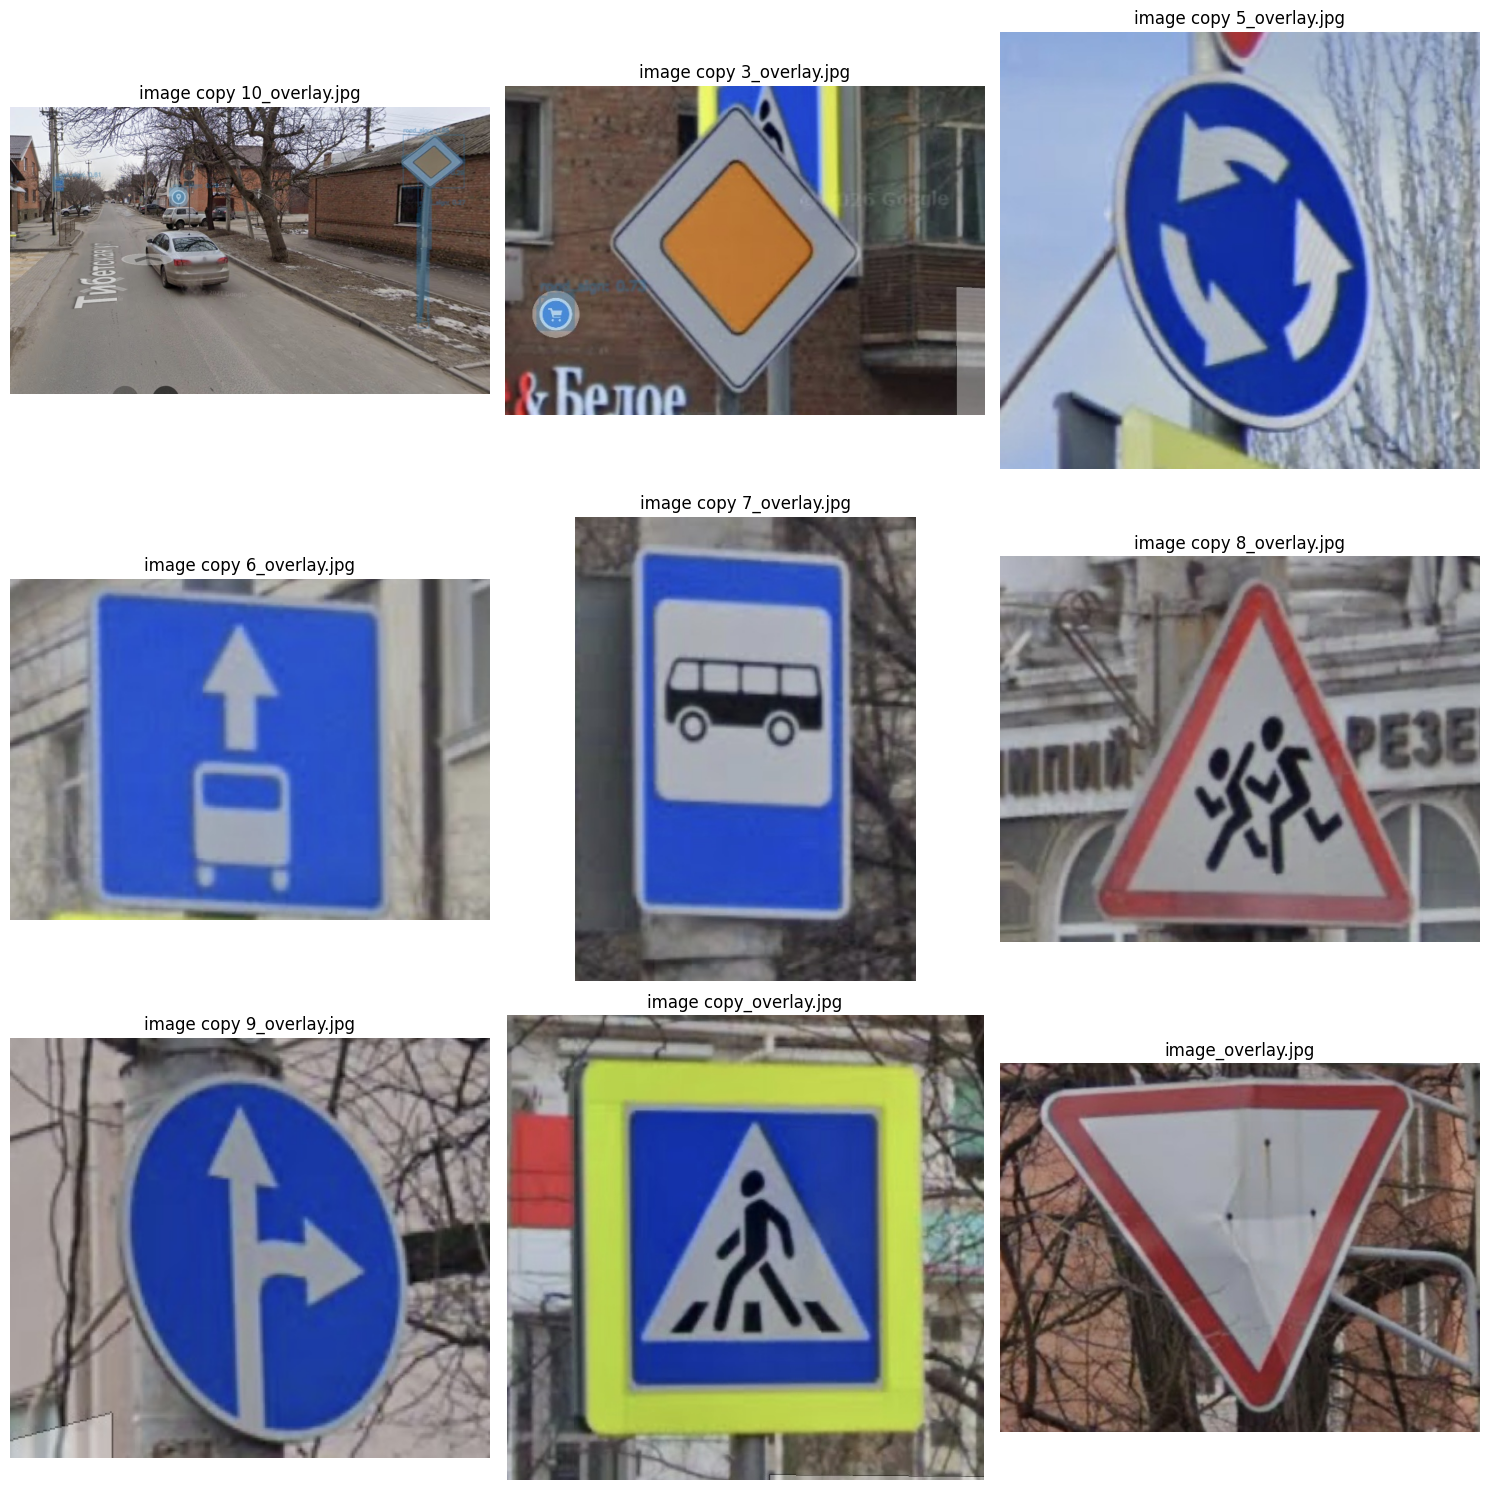

In [16]:
custom_overlay_paths = sorted(CUSTOM_OVERLAY_DIR.glob("*_overlay.jpg"))

n_show = min(9, len(custom_overlay_paths))
if n_show:
    plt.figure(figsize=(15, 5 * ((n_show + 2) // 3)))

    for idx, overlay_path in enumerate(custom_overlay_paths[:n_show], start=1):
        image = cv2.imread(str(overlay_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot((n_show + 2) // 3, 3, idx)
        plt.imshow(image)
        plt.title(overlay_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
